In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # USED ONLY FOR DATA LOADING

In [2]:
# Load the dataset
dataset2_path = r'C:\Users\shiva\OneDrive\Desktop\DA5401_Big_Data_Lab\FML_as1_pca_clustering.ipynb\dataset1-assignment1 - Sheet1.csv'
X2 = pd.read_csv(dataset2_path, header=None).values

print("Shape, minimum value, maximum value:\n", X2.shape, X2.min(), X2.max())
print("First 5 rows:\n", X2[:5, :])


Shape, minimum value, maximum value:
 (1000, 2) -1.423498235 4.439245544
First 5 rows:
 [[2.06031874 2.31662042]
 [3.42607063 2.28227718]
 [3.46444152 0.71631786]
 [2.98230101 3.25647575]
 [0.98648793 0.75841128]]


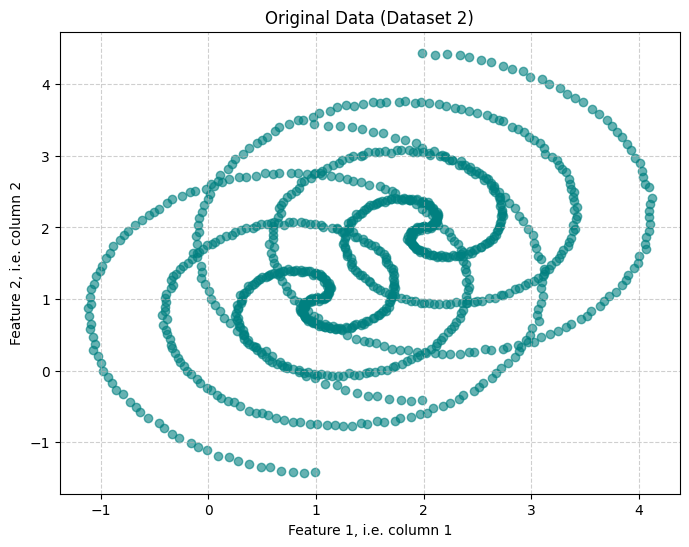

In [3]:
# Visualize  original data
plt.figure(figsize=(8, 6))
plt.scatter(X2[:, 0], X2[:, 1], c='teal', alpha=0.6)
plt.title('Original Data (Dataset 2)')
plt.xlabel('Feature 1, i.e. column 1',)
plt.ylabel('Feature 2, i.e. column 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Implement Kmeans Clustering from Scratch
Implement K-means from scratch and run it with k=4 for 5 different random initializations.


In [4]:
class KMeans:
    """K-means clustering implementation from scratch."""
    def __init__(self, k=4, max_iters=100, random_state=None):
        self.k = k
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.error_history = []

    def _initialize_centroids(self, X):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        random_idx = np.random.permutation(X.shape[0])
        self.centroids = X[random_idx[:self.k]]

    def _assign_clusters(self, X):
        distances = np.zeros((X.shape[0], self.k))
        for i in range(self.k):
            distances[:, i] = np.linalg.norm(X - self.centroids[i], axis=1)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = np.zeros((self.k, X.shape[1]))
        for i in range(self.k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_centroids[i] = np.mean(cluster_points, axis=0)
        return new_centroids
        
    def _compute_error(self, X, labels):
        error = 0
        for i in range(self.k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                error += np.sum((cluster_points - self.centroids[i])**2)
        return error

    def fit(self, X):
        self.error_history = []
        self._initialize_centroids(X)
        for i in range(self.max_iters):
            labels = self._assign_clusters(X)
            self.error_history.append(self._compute_error(X, labels))
            new_centroids = self._update_centroids(X, labels)
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids
        return self._assign_clusters(X)


## Run K means

In [5]:
print("Running K-means with k=4 for 5 different initializations:")
num_runs = 5
k = 4 # no. of centroids, i.e. clusters

for run in range(num_runs):
    print(f"Run index:  {run+1}/{num_runs}")
    kmeans = KMeans(k=k, max_iters=100, random_state=run)
    labels = kmeans.fit(X2)



Running K-means with k=4 for 5 different initializations:
Run index:  1/5
Run index:  2/5
Run index:  3/5
Run index:  4/5
Run index:  5/5


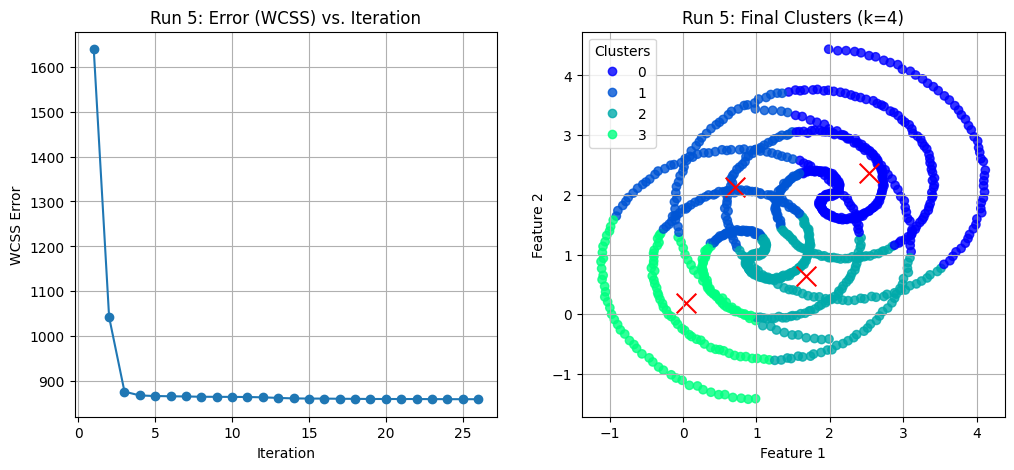

In [6]:
# plot the clusters and error history for each run
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(kmeans.error_history) + 1), kmeans.error_history, marker='o')
plt.title(f'Run {run+1}: Error (WCSS) vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('WCSS Error')
plt.grid(True)

plt.subplot(1, 2, 2)
scatter = plt.scatter(X2[:, 0], X2[:, 1], c=labels, cmap='winter', alpha=0.8)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title(f'Run {run+1}: Final Clusters (k={k})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.grid(True)

## Plot Voronoi Regions

Run K-means for K = {2, 3, 4, 5} with a fixed initialization and
plot the Voronoi regions.


In [7]:
# helper function to plot Voronoi regions

def plot_voronoi(X, kmeans_model, k):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    temp_model = KMeans(k=k)
    temp_model.centroids = kmeans_model.centroids
    Z = temp_model._assign_clusters(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='winter')
    plt.scatter(X[:, 0], X[:, 1], c=kmeans_model._assign_clusters(X), s=20, cmap='viridis', edgecolor='k')
    plt.scatter(kmeans_model.centroids[:, 0], kmeans_model.centroids[:, 1], c='red', marker='x', s=200)
    plt.title(f'K-means Clustering and Voronoi Regions (K={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()


Plots of Voronoi Regions for different K values:
Running for K=2


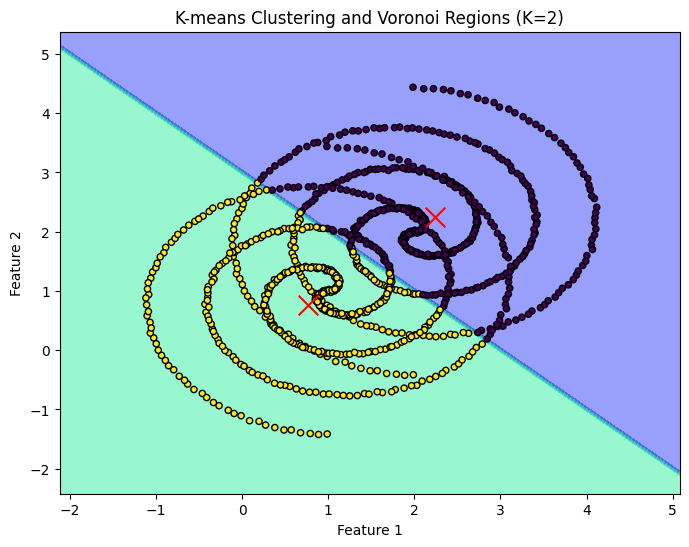

Running for K=3


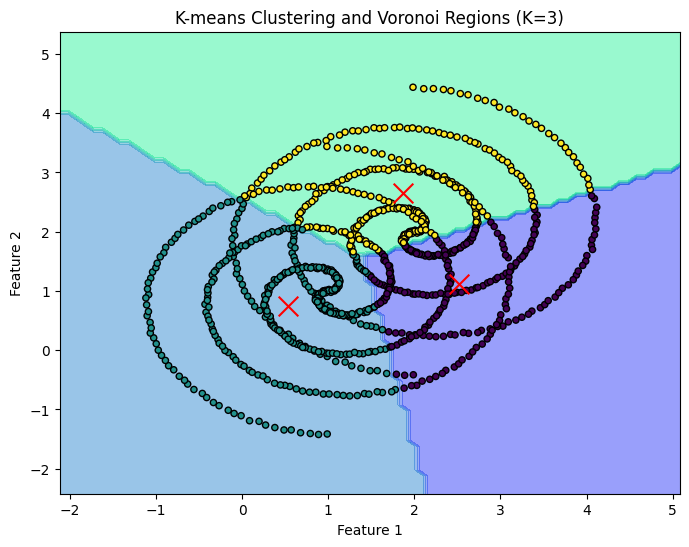

Running for K=4


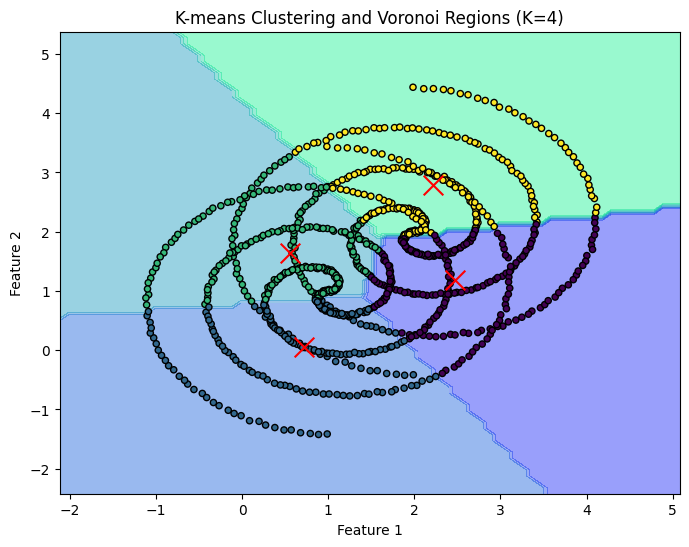

Running for K=5


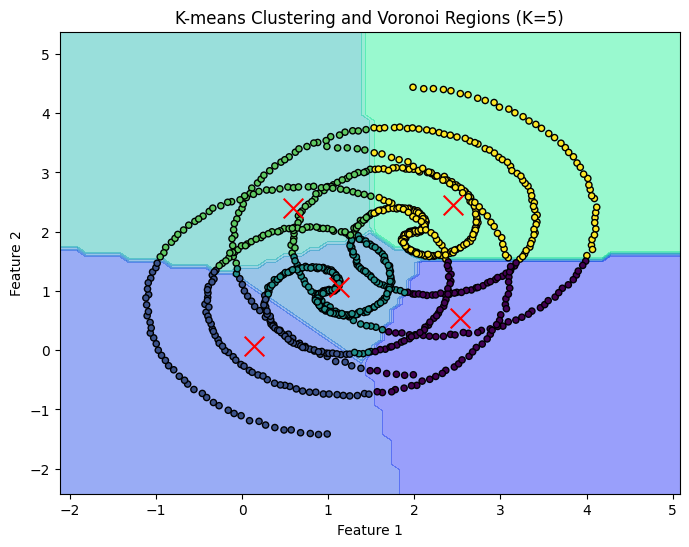

In [8]:
print("Plots of Voronoi Regions for different K values:")
K_values = [2, 3, 4, 5]
fixed_seed = 42

for k_val in K_values:
    print(f"Running for K={k_val}")
    kmeans_voronoi = KMeans(k=k_val, random_state=fixed_seed)
    kmeans_voronoi.fit(X2)
    plot_voronoi(X2, kmeans_voronoi, k=k_val)


# Spectral Clustering 

Implement spectral clustering, which can find non-convex clusters

In [9]:
def rbf_kernel(x1, x2, sigma=1.0):
    sq_dists = -2 * (x1 @ x2.T) + np.sum(x1**2, axis=1)[:, np.newaxis] + np.sum(x2**2, axis=1)
    return np.exp(-sq_dists / (2 * sigma**2))

def polynomial_kernel(x1, x2, degree=2, c=1):
    return (x1 @ x2.T + c) ** degree


In [10]:

class SpectralClustering_rbf:
    def __init__(self, k=4, sigma=1.0, random_state=None):
        self.k = k
        self.sigma = sigma
        self.random_state = random_state

    def fit_predict(self, X):
        W = rbf_kernel(X, X, sigma=self.sigma)
        eigenvalues, eigenvectors = np.linalg.eig(W)
        idx = np.argsort(eigenvalues.real)[::-1]
        eigenvectors = eigenvectors[:, idx]
        V = eigenvectors[:, :self.k].real
        kmeans = KMeans(k=self.k, random_state=self.random_state)
        return kmeans.fit(V)

class SpectralClustering_poly:
    def __init__(self, k=4, degree=2, c=1, random_state=None):
        self.k = k
        self.degree = degree
        self.c = c
        self.random_state = random_state

    def fit_predict(self, X):
        W = polynomial_kernel(X, X, degree=self.degree, c=self.c)
        eigenvalues, eigenvectors = np.linalg.eig(W)
        idx = np.argsort(eigenvalues.real)[::-1]
        eigenvectors = eigenvectors[:, idx]
        V = eigenvectors[:, :self.k].real
        kmeans = KMeans(k=self.k, random_state=self.random_state)
        return kmeans.fit(V)


Running Gaussian Spectral Clustering with k=4


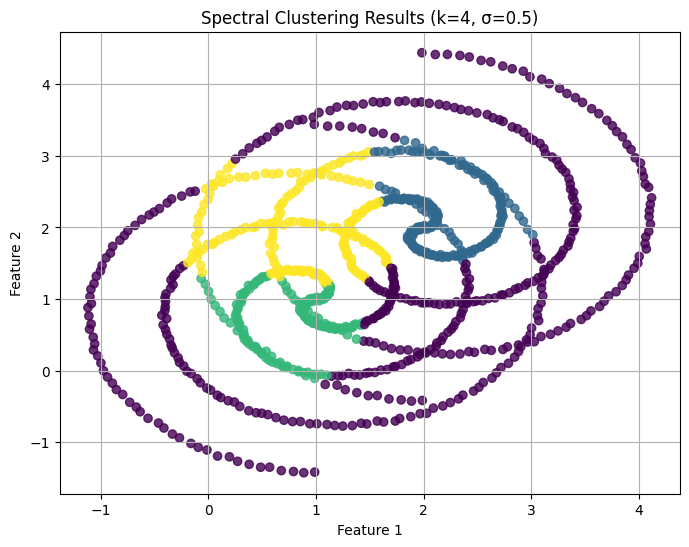

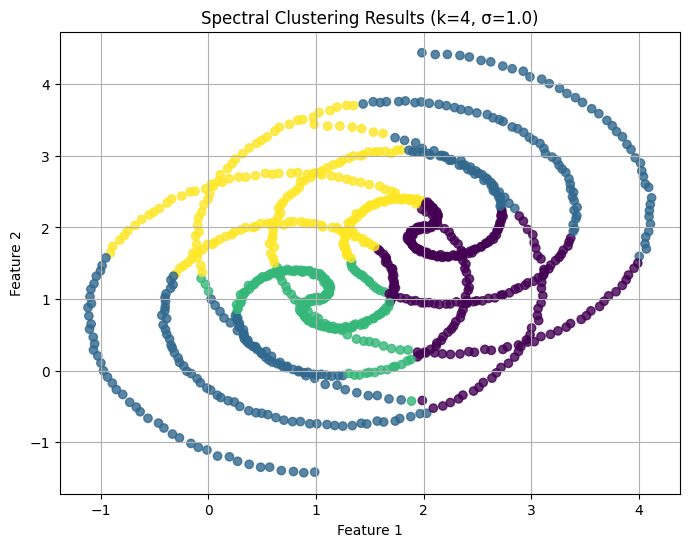

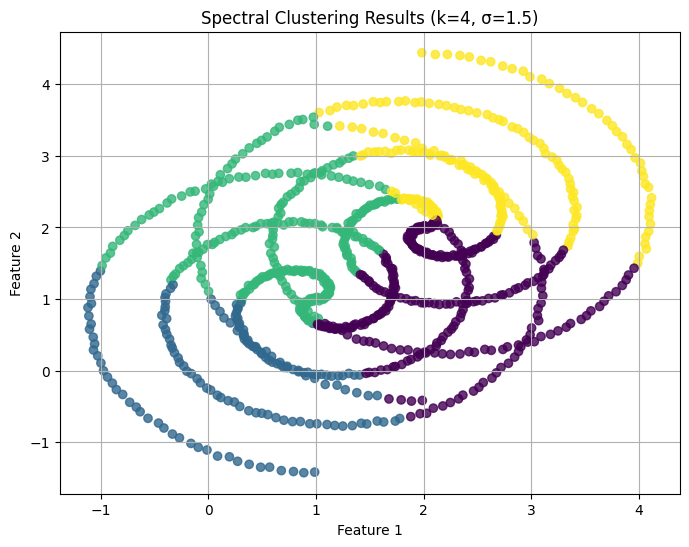

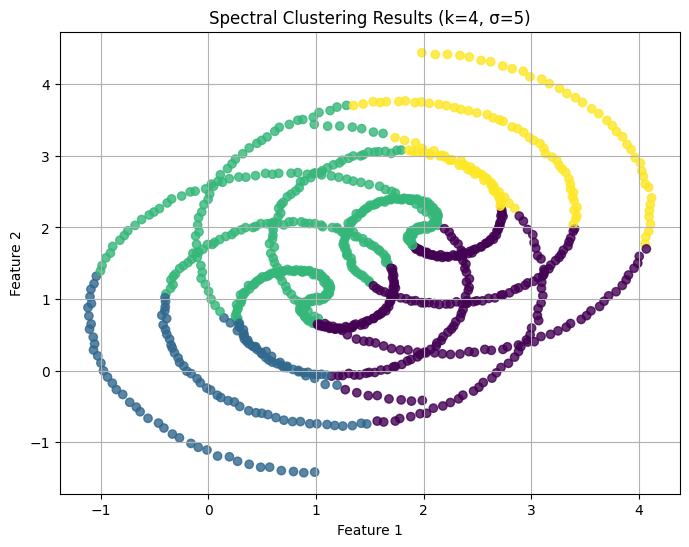

In [14]:
print("Running Gaussian Spectral Clustering with k=4")
sigma_choices = [0.5, 1.0, 1.5, 5]

for sigma in sigma_choices: # This may need tuning based on the data's scale
    spectral = SpectralClustering_rbf(k=4, sigma= sigma, random_state=42)
    labels_spectral = spectral.fit_predict(X2)

    plt.figure(figsize=(8, 6))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels_spectral, cmap='viridis', alpha=0.8)
    plt.title(f'Spectral Clustering Results (k=4, σ={sigma})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.show()

Running Polynomial Spectral Clustering with k=4


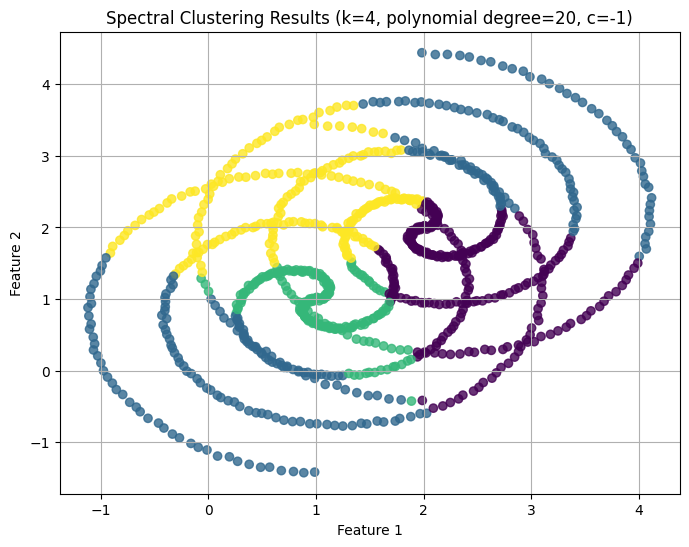

In [12]:
print("Running Polynomial Spectral Clustering with k=4")
poly_degree = 20
poly_c = -1
spectral_poly = SpectralClustering_poly(k=4, degree=poly_degree, c=poly_c, random_state=42)
labels_spectral_poly = spectral_poly.fit_predict(X2)


plt.figure(figsize=(8, 6))
plt.scatter(X2[:, 0], X2[:, 1], c=labels_spectral, cmap='viridis', alpha=0.8)
plt.title(f'Spectral Clustering Results (k=4, polynomial degree={poly_degree}, c={poly_c})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()